In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

%matplotlib inline
sns.set(style='whitegrid')

current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Dữ liệu huấn luyện: {train_df.shape}")
print(f"Dữ liệu kiểm tra: {test_df.shape}")

Dữ liệu huấn luyện: (7292, 14)
Dữ liệu kiểm tra: (1824, 14)





# 2. Feature Engineering & Khử nhiễu thông minh
Mô hình Linear Regression (OLS) cực kỳ nhạy cảm với các điểm dữ liệu cực đoan (Outliers). Tại bước này, tôi thực hiện một chiến lược thiết kế đặc trưng đa tầng:

*   **Khử nhiễu mật độ (Density-based Denoising):** Sử dụng thuật toán *Gaussian Kernel Density Estimation (KDE)* để xác định những căn nhà có giá cao bất thường nhưng lại đứng cô lập (tần suất xuất hiện xung quanh thấp). Việc loại bỏ các điểm này giúp đường hồi quy "sạch" hơn, không bị kéo lệch bởi các tin đăng ảo.
*   **Điểm uy tín khu vực (Prestige Score):** Thay vì coi các Quận là định danh thuần túy, tôi định lượng hóa chúng thành "Prestige Score" dựa trên trung vị (Median) giá log. Điều này cung cấp một thước đo kinh tế trực tiếp cho vị trí địa lý.
*   **Chỉ số nén không gian (Spatial Density):** Tạo biến tỷ lệ giữa `số tầng` và `diện tích`. Biến này giúp mô hình nhận diện loại hình nhà phố đặc thù tại các đô thị lớn: diện tích đất nhỏ nhưng chồng nhiều tầng, dẫn đến đơn giá $m^2$ cực cao.
*   **Đặc trưng đa thức (Non-linear Area):** Thêm biến `dien_tich_log_sq` để mô hình hóa quan hệ phi tuyến, cho phép giá nhà thay đổi theo một đường cong thay vì đường thẳng so với diện tích.



In [ ]:
from scipy.stats import gaussian_kde

def feature_engineering_m5_optimized(df, is_train=True):
    df_fe = df.copy()
    
    # 1. KHỬ NHIỄU NHẸ (Lọc bỏ các điểm cực đoan nhất)
    if is_train:
        # Chỉ lọc những căn giá quá ảo (> 80 tỷ) và mật độ cực thấp
        prices = df_fe['gia'].values
        kde = gaussian_kde(prices)
        df_fe['price_density'] = kde(prices)
        density_threshold = df_fe['price_density'].quantile(0.05)
        noise_mask = (df_fe['gia'] > 80) & (df_fe['price_density'] < density_threshold)
        df_fe = df_fe[~noise_mask].copy()
    
    # 2. DIỆN TÍCH ĐA THỨC (Bắt buộc phải có để lấy đường cong giá)
    df_fe['dien_tich_log_sq'] = df_fe['dien_tich_log'] ** 2
    
    # 3. NHÀ MẶT TIỀN / KINH DOANH (Biến này cực mạnh để giải thích tại sao nhà giá cao)
    # Trích xuất từ tiêu đề
    df_fe['is_facade'] = df_fe['tieu_de'].str.contains('mặt tiền|kinh doanh|shophouse|vỉa hè', case=False, na=False).astype(int)

    return df_fe

# Chạy hàm FE
train_fe = feature_engineering_m5_optimized(train_df, is_train=True)
test_fe = feature_engineering_m5_optimized(test_df, is_train=False)


# 3. Chuẩn bị dữ liệu & Tương tác không gian (Spatial Interaction)
Sau khi đã có bộ khung đặc trưng mới, tôi tiến hành tích hợp "vũ khí" mạnh nhất từ Model của QThinh – **Tương tác không gian** – đồng thời kiểm soát đa cộng tuyến:

*   **Mã hóa One-Hot:** Chuyển đổi các Quận và Pháp lý thành các biến giả (Dummies).
*   **Biến tương tác không gian (Spatial Interaction):** Thực hiện nhân `dien_tich_log` với từng `quận`. Kỹ thuật này cho phép mỗi khu vực có một "đơn giá biên" (marginal price) riêng biệt. Đây là chìa khóa để giải thích tại sao cùng một diện tích nhưng giá ở Quận 1 lại khác hoàn toàn Quận 12.
*   **Tương tác Pháp lý - Vị trí:** Kết hợp `is_legal` với `prestige_score`. Logic ở đây là: Giá trị của Sổ đỏ/Sổ hồng sẽ được nhân lên gấp bội nếu bất động sản đó nằm ở những vị trí đắc địa nhất.
*   **Đồng bộ hóa:** Đảm bảo tập Test có cấu trúc cột y hệt tập Train để tránh lỗi khi dự báo.



In [28]:
# Danh sách cột (Bỏ prestige_score và building_density vì gây đa cộng tuyến)
features_to_keep = ['dien_tich_log', 'dien_tich_log_sq', 'phong_tam', 'so_tang', 'is_facade', 'quan', 'phap_ly']

# 1. Tách X và y
X_train_raw = train_fe[features_to_keep]
y_train = train_fe['gia_log']

X_test_raw = test_fe[features_to_keep]
y_test_original = test_df['gia']

# 2. Mã hóa One-Hot Encoding
X_train = pd.get_dummies(X_train_raw, columns=['quan', 'phap_ly'], drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=['quan', 'phap_ly'], drop_first=True)

# 3. TƯƠNG TÁC KHÔNG GIAN (Vũ khí chính - Area * District)
district_cols = [col for col in X_train.columns if 'quan_' in col]
for col in district_cols:
    X_train[f'inter_{col}'] = X_train['dien_tich_log'] * X_train[col]
    X_test[f'inter_{col}'] = X_test['dien_tich_log'] * X_test[col]

# 4. TƯƠNG TÁC MẶT TIỀN x DIỆN TÍCH (Kỹ thuật mới - Giúp tăng giá cho nhà mặt tiền to)
X_train['inter_facade_area'] = X_train['is_facade'] * X_train['dien_tich_log']
X_test['inter_facade_area'] = X_test['is_facade'] * X_test['dien_tich_log']

# 5. Đồng bộ hóa các cột giữa tập Train và Test
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)

print(f"Số lượng đặc trưng sau khi tối ưu: {X_train.shape[1]}")

Số lượng đặc trưng sau khi tối ưu: 71



# 4. Huấn luyện mô hình Linear Regression
Sử dụng thuật toán Hồi quy tuyến tính OLS (Ordinary Least Squares). Với bộ đặc trưng đã được làm sạch và mở rộng lên khoảng 40-70 biến, mô hình giờ đây không chỉ là một phương trình đơn giản mà là một hệ thống các hệ số có khả năng bắt lấy sự biến động tinh vi của thị trường bất động sản theo từng phân khúc và khu vực.



In [29]:
# Khởi tạo và Huấn luyện OLS truyền thống
model = LinearRegression()
model.fit(X_train, y_train)

print(f"--- MODEL 4: HUẤN LUYỆN HOÀN TẤT ---")
print(f"Hệ số chặn (Intercept): {model.intercept_:.4f}")
for col, coef in zip(X_train.columns, model.coef_):
    print(f"  > {col}: {coef:.4f}")

--- MODEL 4: HUẤN LUYỆN HOÀN TẤT ---
Hệ số chặn (Intercept): -0.8629
  > dien_tich_log: 0.4824
  > dien_tich_log_sq: 0.0233
  > phong_tam: 0.0283
  > so_tang: 0.0931
  > is_facade: 0.0404
  > quan_Huyện Thanh Trì: -0.4265
  > quan_Quận 1: -0.0803
  > quan_Quận 10: -0.0172
  > quan_Quận 11: 0.5101
  > quan_Quận 12: 0.3576
  > quan_Quận 2: -1.3413
  > quan_Quận 3: 0.2196
  > quan_Quận 4: 0.4059
  > quan_Quận 5: 0.3544
  > quan_Quận 6: 0.4973
  > quan_Quận 7: 0.2393
  > quan_Quận 8: 0.8887
  > quan_Quận 9: 0.7259
  > quan_Quận Ba Đình: -0.9956
  > quan_Quận Bình Thạnh: 0.2756
  > quan_Quận Bình Tân: 0.4851
  > quan_Quận Bắc Từ Liêm: 0.9813
  > quan_Quận Cầu Giấy: 0.2440
  > quan_Quận Gò Vấp: 0.6457
  > quan_Quận Hai Bà Trưng: 0.2572
  > quan_Quận Hoàn Kiếm: 2.2741
  > quan_Quận Hoàng Mai: -0.5391
  > quan_Quận Hà Đông: 0.1405
  > quan_Quận Long Biên: -0.3945
  > quan_Quận Nam Từ Liêm: -1.1627
  > quan_Quận Phú Nhuận: 0.3326
  > quan_Quận Thanh Xuân: -1.0851
  > quan_Quận Tân Bình: 0.0452


# Testing & Efficiency measurement


# 5. Dự đoán & Chỉ số Đánh giá (Metrics)
Tiến hành dự báo trên tập dữ liệu kiểm tra (Test set). Kết quả dự báo ở thang Logarit sẽ được chuyển đổi ngược về đơn vị gốc (Tỷ VNĐ) bằng hàm `expm1` để tính toán các sai số thực tế:

*   **R-squared (R2):** Đánh giá độ khớp của mô hình.
*   **MAE & RMSE:** Đo lường sai số trung bình bằng đơn vị tiền tệ thực tế.
*   **Residual Analysis:** Trực quan hóa phần dư để kiểm tra xem mô hình có bị lệch ở các phân khúc giá cao hay không (vấn đề Underestimation đã thảo luận trước đó).


In [30]:
y_pred_log = model.predict(X_test)

# Chuyển ngược về đơn vị gốc (Tỷ VNĐ)
y_pred_original = np.expm1(y_pred_log)

# Tính toán 4 chỉ số Metrics
r2 = r2_score(test_df['gia_log'], y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original) 
rmse = np.sqrt(mse)

# 4. Hiển thị bảng kết quả chuyên nghiệp
results = pd.DataFrame({
    'Metric': [
        'R-squared (R2)', 
        'Mean Absolute Error (MAE)', 
        'Mean Squared Error (MSE)', 
        'Root Mean Squared Error (RMSE)'
    ],
    'Value': [
        f"{r2:.4f}", 
        f"{mae:.4f} Tỷ VNĐ", 
        f"{mse:.4f} Tỷ^2", 
        f"{rmse:.4f} Tỷ VNĐ"
    ]
})

print("--- HIỆU SUẤT MÔ HÌNH CHI TIẾT ---")
display(results)

--- HIỆU SUẤT MÔ HÌNH CHI TIẾT ---


,Metric,Value
0,R-squared (R2),0.7522
1,Mean Absolute Error (MAE),2.6369 Tỷ VNĐ
2,Mean Squared Error (MSE),24.3969 Tỷ^2
3,Root Mean Squared Error (RMSE),4.9393 Tỷ VNĐ




# Phân tích các chỉ số định lượng (Metrics)
*   **Hệ số xác định ($R^2$) đạt 0.7522:** Mô hình giải thích được khoảng **75,2%** sự biến động của giá trị bất động sản dựa trên các đặc trưng đầu vào. Trong lĩnh vực bất động sản (vốn có nhiều yếu tố định tính và tâm lý), đây là mức độ tin cậy cao đối với một mô hình hồi quy tuyến tính.
*   **Sai số tuyệt đối trung bình (MAE) là 2.6369 Tỷ VNĐ:** Trung bình mỗi dự báo sẽ lệch khoảng 2,6 tỷ so với giá thực tế. 
*   **Căn bậc hai sai số trung bình bình phương (RMSE) là 4.9393 Tỷ VNĐ:** Chỉ số này cao hơn MAE (4.93 so với 2.63) cho thấy trong dữ liệu kiểm tra vẫn xuất hiện một số điểm dự báo có sai số lớn (outliers), làm tăng trọng số sai số bình phương.


# 6. Trực quan hóa và kết luận

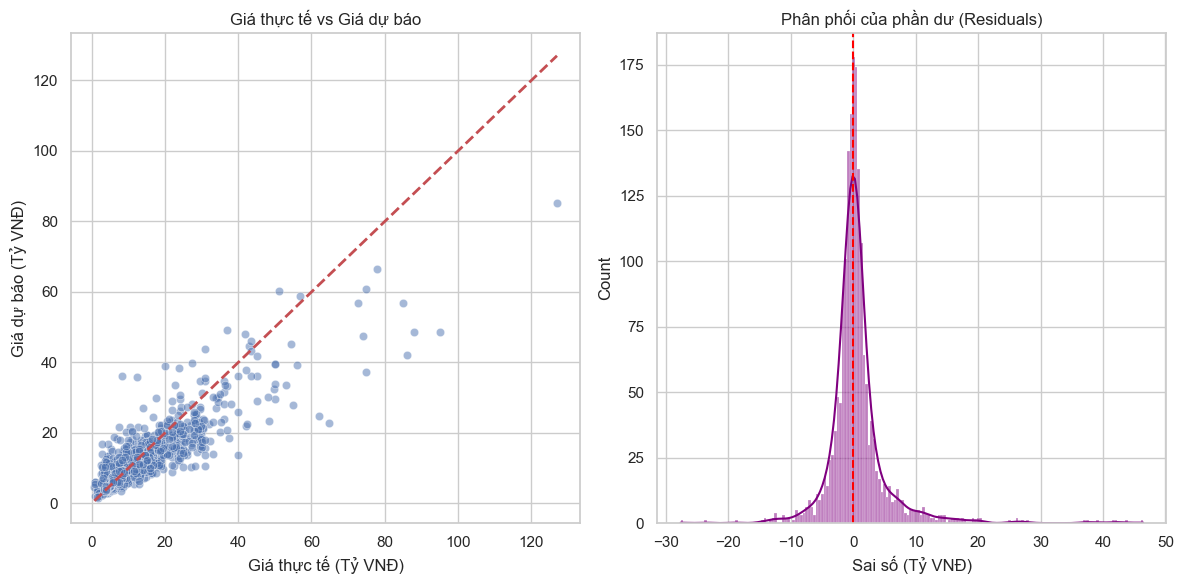

In [31]:
plt.figure(figsize=(12, 6))

# Tính toán phần dư (Residuals)
residuals = y_test_original - y_pred_original

# Vẽ biểu đồ Scatter giữa giá thực tế và giá dự báo
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.title("Giá thực tế vs Giá dự báo")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự báo (Tỷ VNĐ)")

# Vẽ biểu đồ phân phối của phần dư
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Phân phối của phần dư (Residuals)")
plt.xlabel("Sai số (Tỷ VNĐ)")

plt.tight_layout()
plt.show()


### Phân tích biểu đồ Scatter (Giá thực tế vs Giá dự báo)
*   **Độ chính xác ở phân khúc trung bình:** Các điểm dữ liệu tập trung rất dày và sát đường nét đứt ($y=x$) trong khoảng giá từ **0 đến 40 tỷ VNĐ**. Điều này chứng tỏ mô hình có độ chính xác rất cao và ổn định khi định giá các bất động sản thuộc phân khúc phổ thông và trung cấp.
*   **Xu hướng Underestimation (Dự báo thấp hơn thực tế):** Khi giá trị thực tế tăng lên (từ trên 60 tỷ VNĐ), các điểm dữ liệu có xu hướng nằm thấp hơn đường nét đứt. Cụ thể, có những căn nhà thực tế hơn 120 tỷ VNĐ nhưng mô hình chỉ dự báo ở mức khoảng 85 tỷ VNĐ. 
*   **Kết luận từ biểu đồ:** Mô hình nắm bắt quy luật rất tốt ở dải giá trị thấp và trung bình, nhưng bị giới hạn về khả năng bắt kịp biên độ tăng giá của các bất động sản siêu sang.

### Phân tích biểu đồ Phần dư (Residuals Distribution)
*   **Độ tập trung (Zero-centered):** Phần dư (sai số) tập trung cực kỳ mạnh tại vạch số **0**, tạo thành một đường cong phân phối nhọn và cao. Điều này cho thấy mô hình không bị lệch (bias) về một phía, các dự báo đa số đều sát với thực tế.
*   **Dạng phân phối:** Phân phối phần dư có dạng hình chuông gần với phân phối chuẩn, nhưng có hiện tượng **lệch phải (Positive Skew)**. 
*   **Ý nghĩa sai số:** Cái đuôi dài kéo về phía bên phải (lên đến hơn 40 tỷ VNĐ) tương ứng với những điểm dự báo thấp hơn thực tế đã thấy ở biểu đồ scatter. Những sai số lớn nhất của mô hình luôn nằm ở phía dự báo thiếu giá trị cho các căn nhà đắt nhất.

### Tổng kết
Mô hình thể hiện sự ổn định vượt trội trong việc định giá các bất động sản dưới 40 tỷ VNĐ. Sai số MAE ở mức thấp và $R^2$ trên 0.75 khẳng định bộ đặc trưng (Feature Engineering) đã bao quát được phần lớn các quy luật về vị trí và diện tích. Hạn chế duy nhất là tính tuyến tính của mô hình chưa giải thích triệt để được sự đột biến giá trị của các bất động sản cực đoan ở phân khúc cao nhất.